In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision
from data.dataloader import dataloader
from GANs.generator import Generator
from GANs.discriminator import Discriminator
from GANs.methods import weight_init, training
from torchinfo import summary
from PIL import Image

In [2]:
print(torch.__version__)
print(torch.cuda.is_available())

2.9.1+cu128
True


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
latent_dim = 100

noise_z = torch.randn(batch_size, latent_dim, 1, 1, device=device)
train_loader, test_loader = dataloader('CelebA', batch_size=batch_size, img_size=128)

Downloading...
From (original): https://drive.google.com/uc?id=0B7EVK8r0v71pZjFTYXZWM3FlRnM
From (redirected): https://drive.usercontent.google.com/download?id=0B7EVK8r0v71pZjFTYXZWM3FlRnM&confirm=t&uuid=8b6bc49e-28a9-4730-87dd-34e89890d5a4
To: /home/aki/quantum-gan/Quantum-GAN/data/celeba/img_align_celeba.zip
100%|██████████| 1.44G/1.44G [00:23<00:00, 62.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pblRyaVFSWGxPY0U
To: /home/aki/quantum-gan/Quantum-GAN/data/celeba/list_attr_celeba.txt
100%|██████████| 26.7M/26.7M [00:00<00:00, 47.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1_ee_0u7vcNLOfNLegJRHmolfH5ICW-XS
To: /home/aki/quantum-gan/Quantum-GAN/data/celeba/identity_CelebA.txt
100%|██████████| 3.42M/3.42M [00:00<00:00, 35.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pbThiMVRxWXZ4dU0
To: /home/aki/quantum-gan/Quantum-GAN/data/celeba/list_bbox_celeba.txt
100%|██████████| 6.08M/6.08M [00:00<00:00, 34.2MB/s]
Downloading...
F

<class 'PIL.JpegImagePlugin.JpegImageFile'> (178, 218)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9137255..1.0].


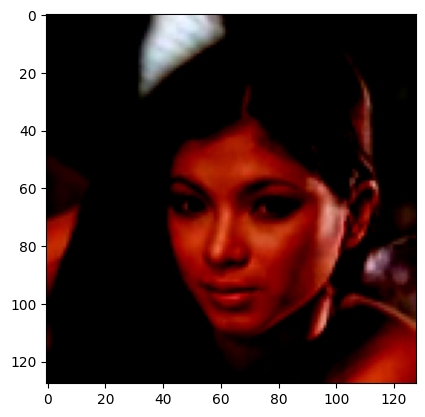

In [9]:
img = Image.open('./data/celeba/img_align_celeba/000010.jpg')
print(type(img), img.size)
plt.imshow(img)
plt.plot()
plt.close()

for batch in train_loader:
  plt.imshow(batch[0][2].permute(1, 2, 0))
  plt.plot()
  break

In [15]:
generator = Generator(latent_dim=latent_dim, img_channels=3, num_features=128, bias=False)
discriminator = Discriminator(in_channels=3, num_features=128, bias=False)

# summary(generator, input_size=(batch_size, latent_dim, 1, 1))
# summary(discriminator, input_size=(batch_size, 3, 128, 128))

generator.apply(weight_init), discriminator.apply(weight_init)

(Generator(
   (generator): Sequential(
     (0): GenBlock(
       (conv): ConvTranspose2d(100, 1024, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1), bias=False)
       (norm): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (relu): ReLU(inplace=True)
     )
     (1): GenBlock(
       (conv): ConvTranspose2d(1024, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
       (norm): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (relu): ReLU(inplace=True)
     )
     (2): GenBlock(
       (conv): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
       (norm): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (relu): ReLU(inplace=True)
     )
     (3): GenBlock(
       (conv): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
       (norm): BatchNorm2d(128, eps=1e-05, momentu

In [11]:
summary(generator, input_size=(batch_size, latent_dim, 1, 1))

Layer (type:depth-idx)                   Output Shape              Param #
Generator                                [128, 3, 128, 128]        --
├─Sequential: 1-1                        [128, 3, 128, 128]        --
│    └─GenBlock: 2-1                     [128, 1024, 2, 2]         --
│    │    └─ConvTranspose2d: 3-1         [128, 1024, 2, 2]         1,638,400
│    │    └─BatchNorm2d: 3-2             [128, 1024, 2, 2]         2,048
│    │    └─ReLU: 3-3                    [128, 1024, 2, 2]         --
│    └─GenBlock: 2-2                     [128, 512, 4, 4]          --
│    │    └─ConvTranspose2d: 3-4         [128, 512, 4, 4]          8,388,608
│    │    └─BatchNorm2d: 3-5             [128, 512, 4, 4]          1,024
│    │    └─ReLU: 3-6                    [128, 512, 4, 4]          --
│    └─GenBlock: 2-3                     [128, 256, 8, 8]          --
│    │    └─ConvTranspose2d: 3-7         [128, 256, 8, 8]          2,097,152
│    │    └─BatchNorm2d: 3-8             [128, 256, 8, 8] 

In [16]:
summary(discriminator, input_size=(batch_size, 3, 128, 128))

Layer (type:depth-idx)                   Output Shape              Param #
Discriminator                            [128]                     --
├─Sequential: 1-1                        [128, 1, 1, 1]            --
│    └─Conv2d: 2-1                       [128, 32, 64, 64]         1,536
│    └─LeakyReLU: 2-2                    [128, 32, 64, 64]         --
│    └─DiscBlock: 2-3                    [128, 64, 32, 32]         --
│    │    └─Conv2d: 3-1                  [128, 64, 32, 32]         32,768
│    │    └─LeakyReLU: 3-2               [128, 64, 32, 32]         --
│    └─DiscBlock: 2-4                    [128, 128, 16, 16]        --
│    │    └─Conv2d: 3-3                  [128, 128, 16, 16]        131,072
│    │    └─LeakyReLU: 3-4               [128, 128, 16, 16]        --
│    └─DiscBlock: 2-5                    [128, 256, 8, 8]          --
│    │    └─Conv2d: 3-5                  [128, 256, 8, 8]          524,288
│    │    └─LeakyReLU: 3-6               [128, 256, 8, 8]          -

In [20]:
from data.dataset import CelebaDataset
from torch.utils.data import DataLoader

celeb_data = CelebaDataset(path="./data", img_size=128)
celeb_loader = DataLoader(celeb_data, batch_size=128, shuffle=True)

for batch in celeb_loader:
    plt.imshow(batch[0][2].permute(1, 2, 0))
    plt.plot()
    plt.axis('off')
    break

ImportError: cannot import name 'CelebaDataset' from 'data.dataset' (/home/aki/quantum-gan/Quantum-GAN/data/dataset.py)

In [18]:
criterion = nn.BCEWithLogitsLoss()
optimizerG = torch.optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
optimizerD = torch.optim.Adam(discriminator.parameters(), lr=5e-5, betas=(0.5, 0.999))  # if it breaks try 5e-5

d_losses, g_losses = training(
    generator=generator,
    discriminator=discriminator,
    train_loader=train_loader,
    epochs=200,
    optimizerG=optimizerG,
    optimizerD=optimizerD,
    criterion=criterion,
    device=device,
    use_amp=True
)

Training Progress:   8%|▊         | 16/200 [2:36:29<29:59:36, 586.83s/it, train_D_loss=0.00571, train_G_loss=0.00566]


KeyboardInterrupt: 

In [19]:
torch.save(generator.state_dict(), 'generator.pth')
torch.save(discriminator.state_dict(), 'discriminator.pth')

In [6]:
from glob import glob
import os

all_imgs = sorted(glob(os.path.join("./data/celeba/img_align_celeba", '*.jpg')))
len(all_imgs)

202599

In [7]:
print(all_imgs[:2])

['./data/celeba/img_align_celeba/000001.jpg', './data/celeba/img_align_celeba/000002.jpg']


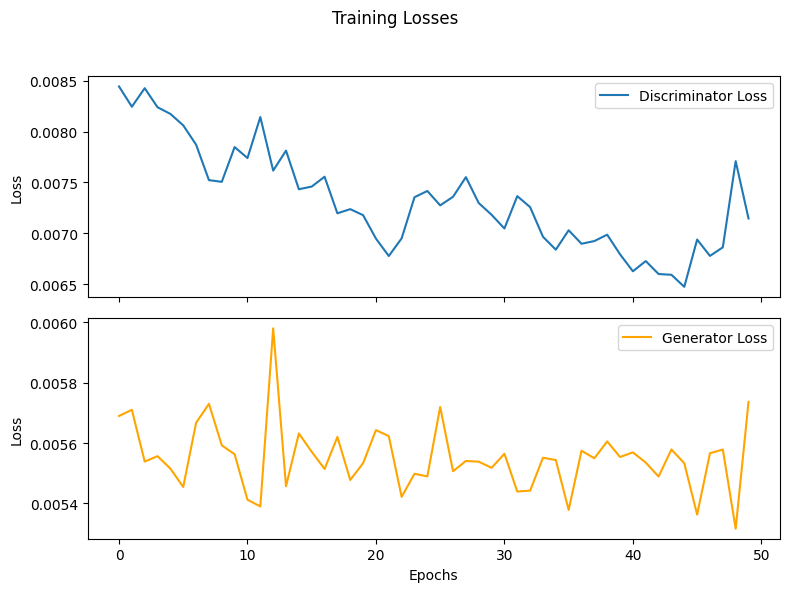

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
fig.suptitle('Training Losses')

axes[0].plot(d_losses, label='Discriminator Loss')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(g_losses, label='Generator Loss', color='orange')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

torch.Size([16, 3, 32, 32])


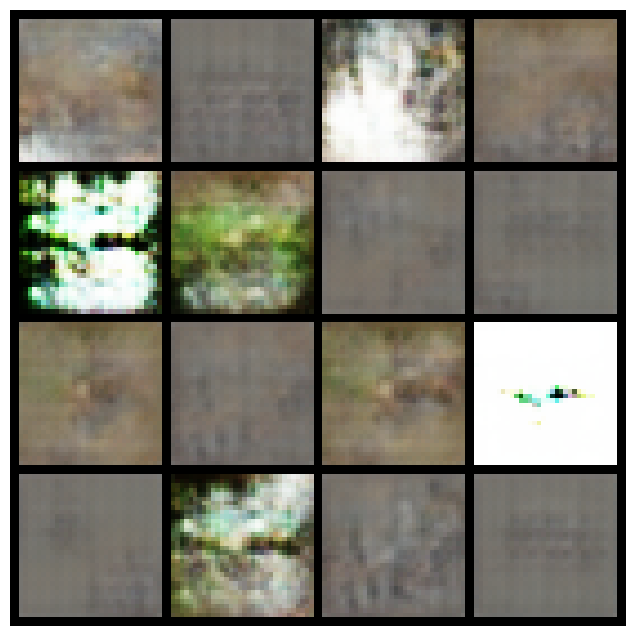

In [ ]:
example = torch.randn(16, latent_dim, 1, 1, device=device)
generator.eval()
with torch.no_grad():
    generator.to(device=device)
    generated_images = generator(example)
    print(generated_images.shape)

grid = torchvision.utils.make_grid(generated_images.cpu(), nrow=4, normalize=True)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis('off')
plt.show()